# Experiment No. 6
# Decision Tree and K-Nearest Neighbour (KNN) for Classification

## Aim

To implement **Decision Tree** and **K-Nearest Neighbour (KNN)** classification algorithms using Python and evaluate their performance on the Iris dataset.

## Objectives

- Understand the working of **Decision Tree and KNN**.
- Understand **Entropy, Information Gain, Gini Index, and K value**.
- Implement both algorithms using **Scikit-learn**.
- Evaluate models using **Accuracy, Precision, Recall, F1-score, and Confusion Matrix**.
- Compare the performance of both models.

## Theory

### Decision Tree
A **Decision Tree** classifies data by recursively splitting it based on features. It uses measures such as **Entropy, Information Gain, and Gini Index** to select suitable splits.

### K-Nearest Neighbour (KNN)
**KNN** classifies a new data point based on the majority class of its **K nearest neighbours**. It uses distance measures such as **Euclidean Distance**.

**Important:** Feature scaling is important for KNN because it is distance-based, while Decision Tree generally does not require feature scaling.

## Important Formulas

### Entropy

$$
Entropy = -\sum p_i \log_2(p_i)
$$

### Gini Index

$$
Gini = 1-\sum p_i^2
$$

### Euclidean Distance

$$
d(x,y)=\sqrt{\sum(x_i-y_i)^2}
$$

## Implementation Steps

1. Import required libraries.
2. Load and inspect the dataset.
3. Perform basic data analysis.
4. Split the dataset into training and testing sets.
5. Scale features for KNN.
6. Train Decision Tree and KNN models.
7. Make predictions.
8. Evaluate both models.
9. Compare different K values.
10. Tune KNN parameters.
11. Predict a new sample.

# Step 1 - Import Required Libraries

In this step, we import the libraries required for:

- Data manipulation
- Numerical calculations
- Data visualization
- Decision Tree classification
- KNN classification
- Model evaluation
- Hyperparameter tuning

In [54]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    cross_val_score
)

from sklearn.preprocessing import StandardScaler

from sklearn.tree import (
    DecisionTreeClassifier,
    plot_tree
)

from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("Libraries imported successfully!")

Libraries imported successfully!


# Step 2 - Load the Iris Dataset

The **Iris dataset** contains measurements of iris flowers belonging to three different species:

- **Iris-setosa**
- **Iris-versicolor**
- **Iris-virginica**

The four numerical features are:

1. Sepal Length
2. Sepal Width
3. Petal Length
4. Petal Width

The target variable is the flower species.

In [55]:
url = "https://raw.githubusercontent.com/uiuc-cse/data-fa14/gh-pages/data/iris.csv"

data = pd.read_csv(url)

print("Dataset loaded successfully!")

Dataset loaded successfully!


# Step 3 - Display the First Five Rows

The `head()` function displays the first five records of the dataset.

This allows us to understand the structure and format of the data.

In [56]:
data.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


# Step 4 - Display Dataset Information

The `info()` function provides information about:

- Number of records
- Number of columns
- Column names
- Data types
- Non-null values

This is useful during the initial data inspection.

In [57]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


# Step 5 - Check Dataset Shape

The `shape` attribute returns:

```text
(number of rows, number of columns)

In [58]:
print("Number of rows:", data.shape[0])
print("Number of columns:", data.shape[1])

Number of rows: 150
Number of columns: 5


# Step 6 - Check Missing Values

Missing values can cause problems during machine learning.

Therefore, we check every column to determine whether missing values are present.

In [59]:
print("Missing values:")
print(data.isnull().sum())


Missing values:
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64


# Step 7 - Check Duplicate Records

Duplicate observations can affect data analysis.

We check the dataset for duplicate rows.

In [60]:
print("Number of duplicate rows:", data.duplicated().sum())

Number of duplicate rows: 3


# Step 8 - Generate Statistical Summary

The `describe()` function provides statistical information about the numerical features.

It includes:

- Count
- Mean
- Standard deviation
- Minimum
- Maximum
- 25th percentile
- Median
- 75th percentile

In [61]:
data.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


# Step 9 - Check Target Class Distribution

We count the number of samples belonging to each Iris species.

This helps us determine whether the dataset is approximately balanced across the classes.

In [62]:
print("Class distribution:")
print(data["species"].value_counts())

Class distribution:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


# Step 10 - Visualize Class Distribution

A count plot is used to visualize the number of samples in each class.

This makes it easier to understand the distribution of the target variable.

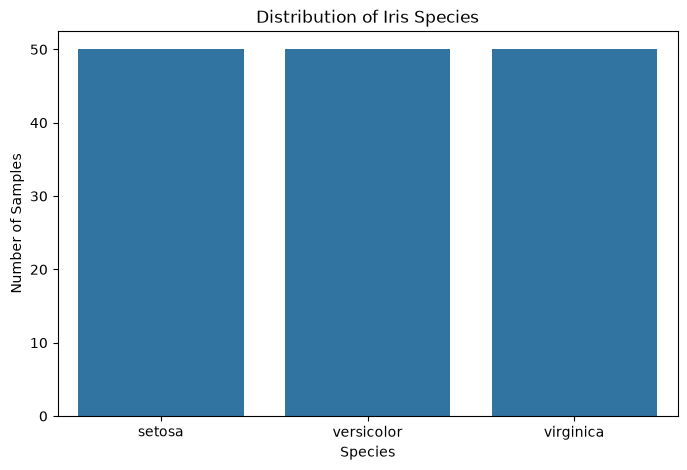

In [63]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=data,
    x="species"
)

plt.title("Distribution of Iris Species")
plt.xlabel("Species")
plt.ylabel("Number of Samples")

plt.show()

# Step 11 - Visualize Feature Relationships

A pair plot displays relationships between the numerical features.

The colors represent different Iris species.

This helps us visually examine whether different classes have separable feature patterns.

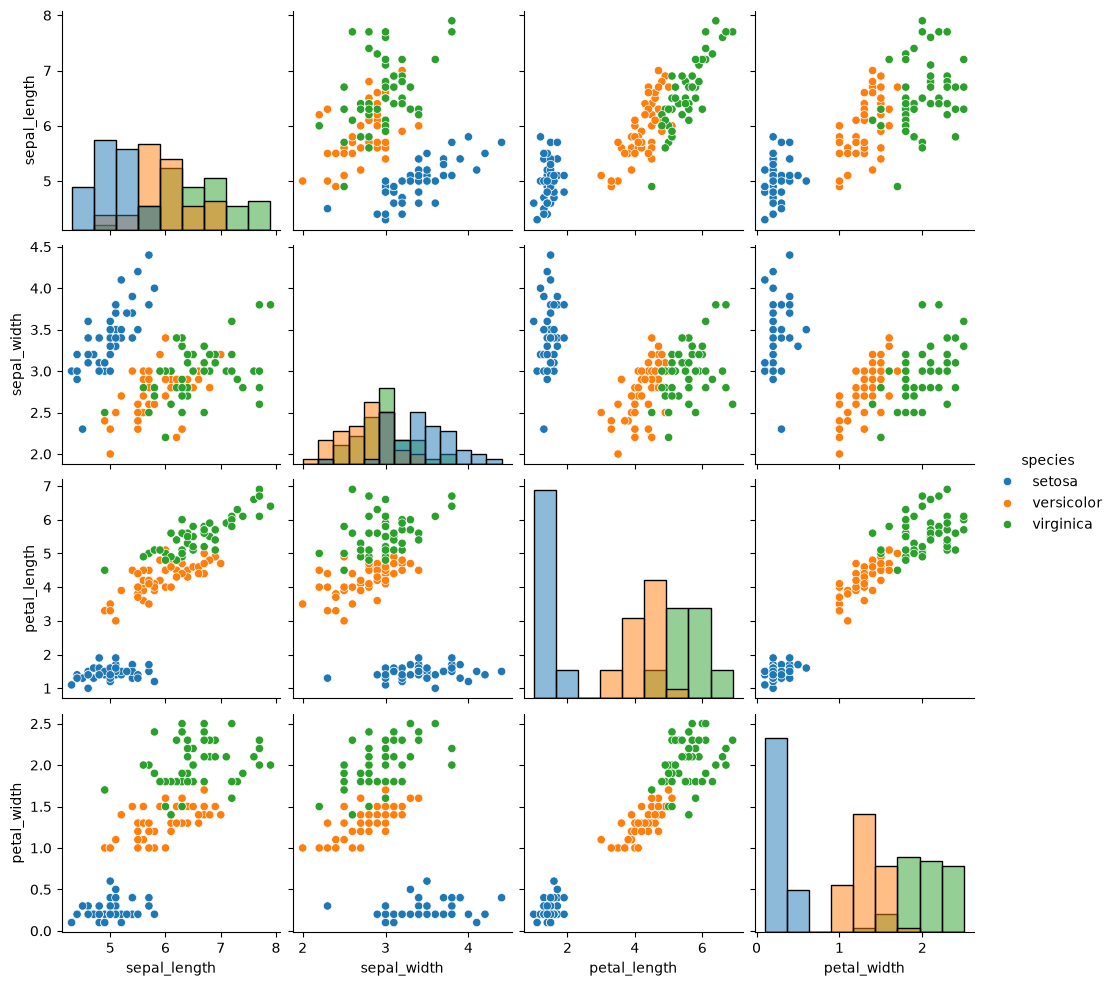

In [64]:
sns.pairplot(
    data,
    hue="species",
    diag_kind="hist"
)

plt.show()

# Step 12 - Generate Correlation Heatmap

Correlation measures the relationship between numerical variables.

A heatmap provides a visual representation of these correlations.

Values closer to:

- **+1** indicate strong positive correlation.
- **-1** indicate strong negative correlation.
- **0** indicate weak or no linear correlation.

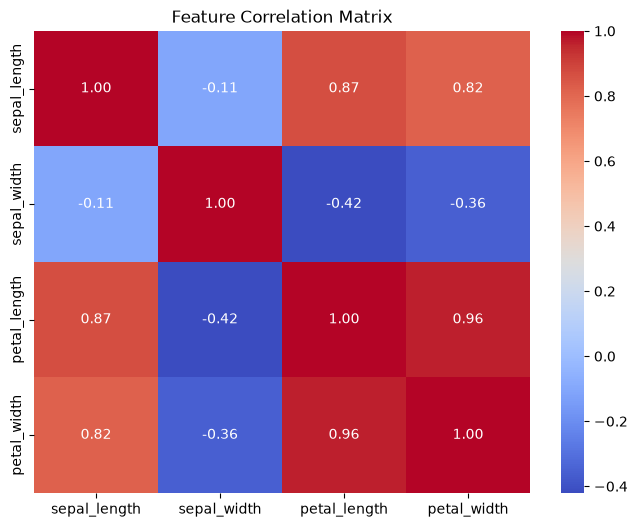

In [65]:
numeric_data = data.drop(columns=["species"])

plt.figure(figsize=(8, 6))

sns.heatmap(
    numeric_data.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Feature Correlation Matrix")
plt.show()

# Step 13 - Separate Features and Target

The dataset is divided into:

### X — Features

The four flower measurements:

- Sepal Length
- Sepal Width
- Petal Length
- Petal Width

### y — Target

The target variable is the flower species.

In [66]:
X = data.drop(columns=["species"])
y = data["species"]

print("Features:")
print(X.head())

print("\nTarget:")
print(y.head())

Features:
   sepal_length  sepal_width  petal_length  petal_width
0           5.1          3.5           1.4          0.2
1           4.9          3.0           1.4          0.2
2           4.7          3.2           1.3          0.2
3           4.6          3.1           1.5          0.2
4           5.0          3.6           1.4          0.2

Target:
0    setosa
1    setosa
2    setosa
3    setosa
4    setosa
Name: species, dtype: object


# Step 14 - Split Dataset into Training and Testing Sets

The dataset is divided into:

- **80% training data**
- **20% testing data**

The training data is used to train the models.

The testing data is used to evaluate performance on unseen data.

`stratify=y` keeps the class proportions approximately consistent between training and testing datasets.

In [67]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 120
Testing samples: 30


# Step 15 - Feature Scaling

Feature scaling is particularly important for **KNN** because KNN calculates distances between data points.

If features have very different scales, a feature with larger numerical values may dominate the distance calculation.

We use `StandardScaler`.

Standardization transforms the features approximately to:

- Mean = 0
- Standard deviation = 1

### Important

The scaler is fitted only on the training data.

The testing data is transformed using the same fitted scaler.

In [68]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed successfully.")

Feature scaling completed successfully.


# Step 16 - Train Decision Tree Classifier

We create a Decision Tree classifier using:

```python
criterion="entropy"

In [69]:

dt_model = DecisionTreeClassifier(
    criterion="entropy",
    random_state=42
)

dt_model.fit(
    X_train,
    y_train
)

print("Decision Tree training completed.")

Decision Tree training completed.


# Step 17 - Make Predictions using Decision Tree

The trained Decision Tree is used to predict the classes of the testing samples.

Since Decision Trees do not require distance calculations, we use the **original unscaled test data**.

In [70]:
y_pred_dt = dt_model.predict(X_test)

print("Decision Tree Predictions:")
print(y_pred_dt)

Decision Tree Predictions:
['setosa' 'virginica' 'versicolor' 'versicolor' 'setosa' 'versicolor'
 'setosa' 'setosa' 'virginica' 'versicolor' 'virginica' 'virginica'
 'virginica' 'versicolor' 'setosa' 'setosa' 'setosa' 'versicolor'
 'versicolor' 'virginica' 'setosa' 'virginica' 'versicolor' 'versicolor'
 'virginica' 'virginica' 'versicolor' 'setosa' 'virginica' 'setosa']


# Step 18 - Calculate Decision Tree Accuracy

Accuracy represents the proportion of correctly classified test samples.

$$
Accuracy =
\frac{Correct\ Predictions}
{Total\ Predictions}
$$

In [71]:
dt_accuracy = accuracy_score(
    y_test,
    y_pred_dt
)

print(
    "Decision Tree Accuracy:",
    round(dt_accuracy * 100, 2),
    "%"
)

Decision Tree Accuracy: 93.33 %


# Step 19 - Decision Tree Classification Report

The classification report provides:

- **Precision**
- **Recall**
- **F1-score**
- **Support**

for each Iris species.

These metrics provide more detailed information than accuracy alone.

In [72]:
print("Decision Tree Classification Report:")
print(
    classification_report(
        y_test,
        y_pred_dt
    )
)

Decision Tree Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



# Step 20 - Decision Tree Confusion Matrix

A confusion matrix shows the number of correct and incorrect predictions for each class.

The diagonal represents correctly classified samples.

Off-diagonal values represent misclassifications.

In [73]:
cm_dt = confusion_matrix(
    y_test,
    y_pred_dt
)

print("Decision Tree Confusion Matrix:")
print(cm_dt)

Decision Tree Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  1  9]]


# Step 21 - Visualize the Decision Tree

The trained Decision Tree can be visualized using `plot_tree()`.

This allows us to understand the sequence of decisions used by the model.

Each node displays information such as:

- Feature used for splitting
- Threshold
- Impurity
- Number of samples
- Predicted class

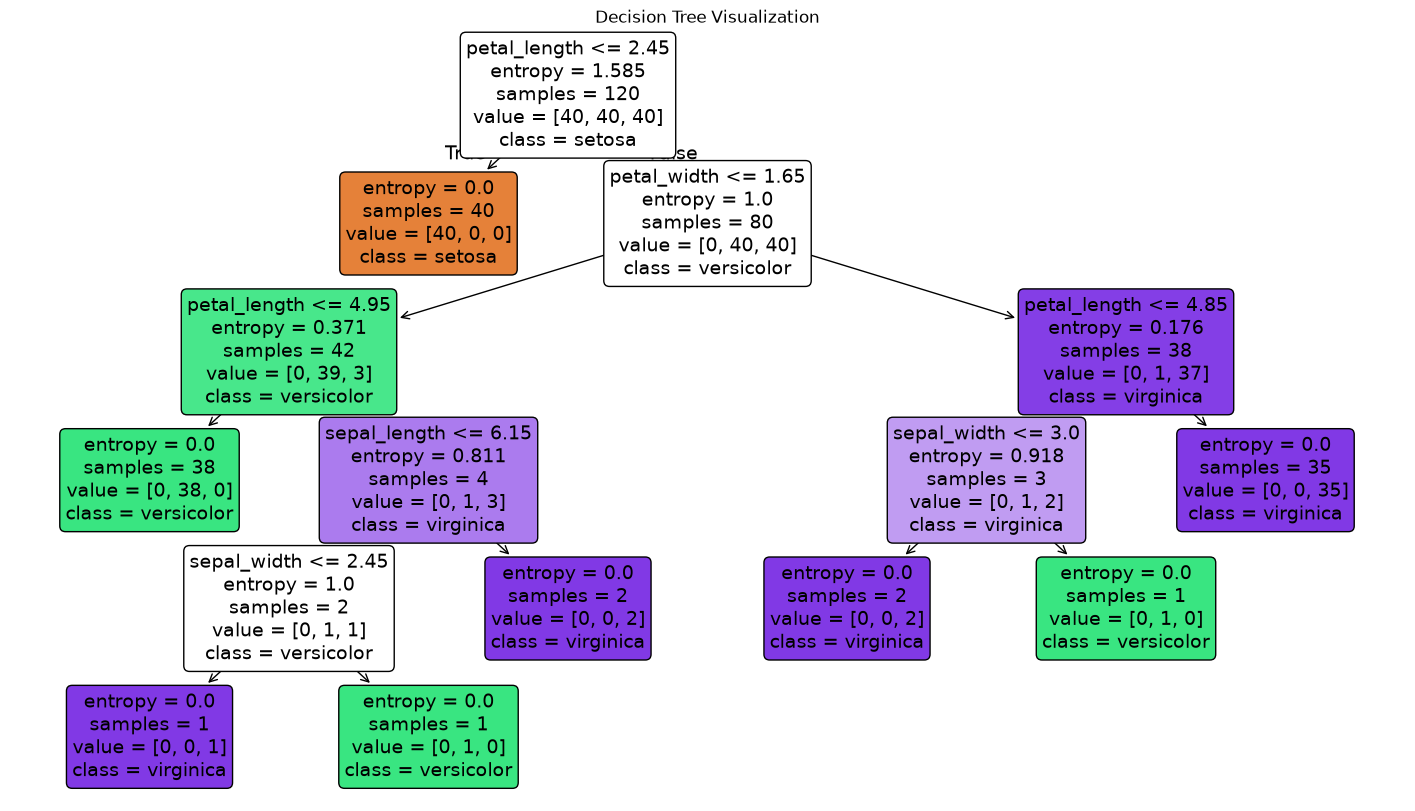

In [74]:
plt.figure(figsize=(18, 10))

plot_tree(
    dt_model,
    feature_names=X.columns,
    class_names=dt_model.classes_,
    filled=True,
    rounded=True
)

plt.title("Decision Tree Visualization")
plt.show()

# Step 22 - Train K-Nearest Neighbour Classifier

We now create a KNN classifier.

Initially, we use:

```text
K = 5

In [75]:
knn_model = KNeighborsClassifier(
    n_neighbors=5
)

knn_model.fit(
    X_train_scaled,
    y_train
)

print("KNN training completed.")

KNN training completed.


# Step 23 - Make Predictions using KNN

The trained KNN model predicts the class of each testing sample.

The testing data must be scaled using the same scaler used for the training data.

In [76]:
y_pred_knn = knn_model.predict(
    X_test_scaled
)

print("KNN Predictions:")
print(y_pred_knn)

KNN Predictions:
['setosa' 'virginica' 'versicolor' 'versicolor' 'setosa' 'versicolor'
 'setosa' 'setosa' 'virginica' 'versicolor' 'virginica' 'virginica'
 'virginica' 'versicolor' 'setosa' 'setosa' 'setosa' 'versicolor'
 'versicolor' 'versicolor' 'setosa' 'virginica' 'versicolor' 'versicolor'
 'virginica' 'versicolor' 'versicolor' 'setosa' 'virginica' 'setosa']


# Step 24 - Evaluate KNN Performance

We calculate the following evaluation metrics:

- **Accuracy**
- **Precision**
- **Recall**
- **F1-score**

These metrics help us understand the performance of the KNN classifier.

In [77]:
knn_accuracy = accuracy_score(
    y_test,
    y_pred_knn
)

knn_precision = precision_score(
    y_test,
    y_pred_knn,
    average="weighted"
)

knn_recall = recall_score(
    y_test,
    y_pred_knn,
    average="weighted"
)

knn_f1 = f1_score(
    y_test,
    y_pred_knn,
    average="weighted"
)

print("KNN Results")
print("=" * 40)

print("Accuracy :", round(knn_accuracy, 4))
print("Precision:", round(knn_precision, 4))
print("Recall   :", round(knn_recall, 4))
print("F1-Score :", round(knn_f1, 4))

KNN Results
Accuracy : 0.9333
Precision: 0.9444
Recall   : 0.9333
F1-Score : 0.9327


# Step 25 - KNN Classification Report

The classification report provides detailed performance metrics for each Iris species.

It helps us understand whether the model performs consistently across all classes.

In [78]:
print("KNN Classification Report:")

print(
    classification_report(
        y_test,
        y_pred_knn
    )
)

KNN Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.83      1.00      0.91        10
   virginica       1.00      0.80      0.89        10

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30



# Step 26 - KNN Confusion Matrix

The confusion matrix shows the actual classes against the predicted classes.

A heatmap is used to make the results easier to interpret visually.

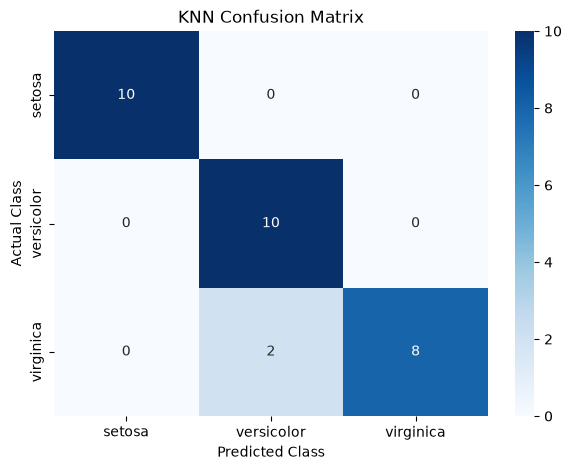

In [79]:
cm_knn = confusion_matrix(
    y_test,
    y_pred_knn
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_knn,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=knn_model.classes_,
    yticklabels=knn_model.classes_
)

plt.title("KNN Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.show()

# Step 27 - Analyze the Effect of K

The value of **K** can significantly affect KNN performance.

We test multiple K values and calculate the testing accuracy for each one.

This helps us understand how changing K affects the classifier.

In [80]:
k_values = range(1, 16)

k_accuracies = []

for k in k_values:
    model = KNeighborsClassifier(
        n_neighbors=k
    )

    model.fit(
        X_train_scaled,
        y_train
    )

    predictions = model.predict(
        X_test_scaled
    )

    accuracy = accuracy_score(
        y_test,
        predictions
    )

    k_accuracies.append(accuracy)

for k, accuracy in zip(k_values, k_accuracies):
    print(
        f"K = {k:2d}  Accuracy = {accuracy * 100:.2f}%"
    )

K =  1  Accuracy = 96.67%
K =  2  Accuracy = 93.33%
K =  3  Accuracy = 93.33%
K =  4  Accuracy = 93.33%
K =  5  Accuracy = 93.33%
K =  6  Accuracy = 93.33%
K =  7  Accuracy = 96.67%
K =  8  Accuracy = 93.33%
K =  9  Accuracy = 96.67%
K = 10  Accuracy = 96.67%
K = 11  Accuracy = 96.67%
K = 12  Accuracy = 96.67%
K = 13  Accuracy = 96.67%
K = 14  Accuracy = 93.33%
K = 15  Accuracy = 96.67%


# Step 28 - Visualize K Value vs Accuracy

A line graph is used to visualize the relationship between the value of K and classification accuracy.

This helps us identify a suitable K value based on the observed test performance.

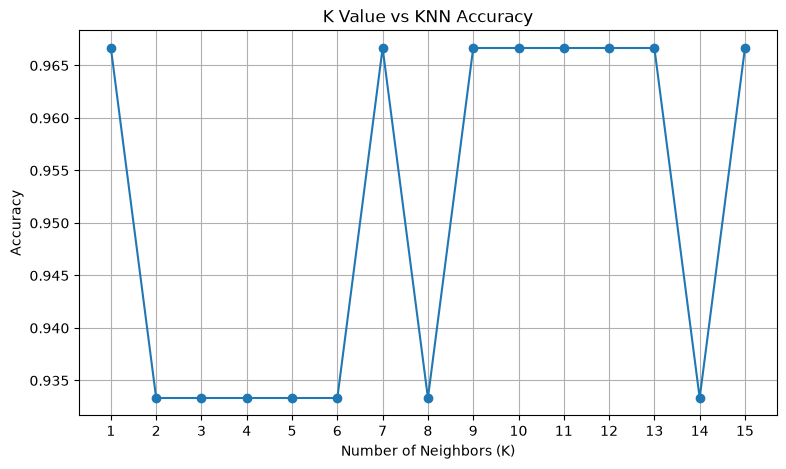

Best K based on test accuracy: 1
Best Test Accuracy: 96.67 %


In [81]:
plt.figure(figsize=(9, 5))

plt.plot(
    list(k_values),
    k_accuracies,
    marker="o"
)

plt.title("K Value vs KNN Accuracy")
plt.xlabel("Number of Neighbors (K)")
plt.ylabel("Accuracy")
plt.xticks(list(k_values))
plt.grid(True)

plt.show()

best_k = list(k_values)[
    np.argmax(k_accuracies)
]

print(
    "Best K based on test accuracy:",
    best_k
)

print(
    "Best Test Accuracy:",
    round(
        max(k_accuracies) * 100,
        2
    ),
    "%"
)

# Step 29 - Hyperparameter Tuning and Model Comparison

We use **GridSearchCV** to find a suitable combination of KNN hyperparameters.

The parameters considered are:

- Number of neighbors
- Distance metric

We use **5-fold cross-validation**.

After tuning KNN, we compare the test accuracy of:

- Decision Tree
- Original KNN
- Tuned KNN

In [ ]:
knn_parameter_grid = {
    "n_neighbors": [3, 5, 7, 9, 11],
    "weights": ["uniform", "distance"],
    "metric": ["euclidean", "manhattan"]
}

knn_grid = GridSearchCV(
    estimator=KNeighborsClassifier(),
    param_grid=knn_parameter_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

knn_grid.fit(
    X_train_scaled,
    y_train
)

best_knn = knn_grid.best_estimator_

y_pred_best_knn = best_knn.predict(
    X_test_scaled
)

best_knn_accuracy = accuracy_score(
    y_test,
    y_pred_best_knn
)

print("Best KNN Parameters:")
print(knn_grid.best_params_)

print(
    "\nBest Cross-Validation Accuracy:",
    round(knn_grid.best_score_, 4)
)

print(
    "\nTuned KNN Test Accuracy:",
    round(best_knn_accuracy * 100, 2),
    "%"
)

print("\nModel Comparison:")
print(
    "Decision Tree Accuracy:",
    round(dt_accuracy * 100, 2),
    "%"
)

print(
    "Original KNN Accuracy:",
    round(knn_accuracy * 100, 2),
    "%"
)

print(
    "Tuned KNN Accuracy:",
    round(best_knn_accuracy * 100, 2),
    "%"
)

# Step 30 - Predict a New Iris Flower

Finally, we use the trained models to classify a new Iris flower.

The sample contains:

- Sepal Length = 5.1
- Sepal Width = 3.5
- Petal Length = 1.4
- Petal Width = 0.2

### Important

The Decision Tree uses the **original feature values**.

The KNN model requires the sample to be **scaled using the same StandardScaler** that was fitted on the training data.

The predictions from both models are displayed.

In [ ]:
# New Iris flower sample
new_sample = pd.DataFrame(
    [[5.1, 3.5, 1.4, 0.2]],
    columns=[
        "sepal_length",
        "sepal_width",
        "petal_length",
        "petal_width"
    ]
)

# Decision Tree prediction
dt_prediction = dt_model.predict(
    new_sample
)

# Scale the new sample for KNN
new_sample_scaled = scaler.transform(
    new_sample
)

# KNN prediction using tuned model
knn_prediction = best_knn.predict(
    new_sample_scaled
)

print("New Iris Flower:")
print(new_sample)

print("\nDecision Tree Prediction:")
print(dt_prediction[0])

print("\nKNN Prediction:")
print(knn_prediction[0])

# 📈 Model Comparison

The following table can be used to summarize the results obtained from the experiment.

| Model | Accuracy | Feature Scaling | Main Parameter |
|---|---:|---|---|
| Decision Tree | Obtained from Step 18 | Not required | Entropy |
| KNN | Obtained from Step 24 | Required | K = 5 |
| Tuned KNN | Obtained from Step 29 | Required | GridSearchCV |

The actual values should be filled using the output generated by the notebook.


---

# 📝 CONCLUSION
In this experiment, **Decision Tree** and **K-Nearest Neighbour (KNN)** classification algorithms were successfully implemented using Python and Scikit-learn on the Iris dataset.

The Decision Tree classified samples by recursively splitting the dataset using decision rules based on **Entropy and Information Gain**.

The KNN algorithm classified samples based on the classes of their nearest neighbours using a distance-based voting mechanism.

The models were evaluated using:

- **Accuracy**
- **Precision**
- **Recall**
- **F1-score**
- **Confusion Matrix**
- **Classification Report**

The Decision Tree was visualized to understand its decision-making process.

For KNN, feature scaling was performed because KNN depends on distance calculations. Different values of K were tested to study their effect on model performance, and **GridSearchCV** was used for hyperparameter tuning.

The experiment demonstrates that both Decision Tree and KNN can be effective classification algorithms, but they have different characteristics. Decision Trees are generally easier to interpret and do not require feature scaling, whereas KNN is sensitive to feature scaling and the choice of K.

Therefore, selecting an appropriate algorithm depends on the characteristics of the dataset, computational requirements, interpretability requirements, and model performance.